In [1]:
# ---------------------------------------------------------------
# Import necessary libraries
# ---------------------------------------------------------------
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, recall_score, precision_score, f1_score, balanced_accuracy_score, roc_auc_score
from sklearn.inspection import permutation_importance
from scipy.stats import wilcoxon
from xgboost import XGBClassifier
from collections import Counter

In [2]:
# ---------------------------
# Load data
# ---------------------------
df = pd.read_csv("../data/final_data.csv")
TARGET = "P_HABITABLE"
X = df.drop(columns=[TARGET])
y = df[TARGET].values

In [3]:
# ---------------------------
# Hold-out test (fixed)
# ---------------------------
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
print("Train+val size:", X_trainval.shape, "Test size:", X_test.shape)

Train+val size: (4224, 15) Test size: (1057, 15)


In [4]:
# ---------------------------
# Models & param grids
# ---------------------------

models = {
    "RandomForest": (
        RandomForestClassifier(class_weight="balanced", n_jobs=-1, random_state=42),
        {"clf__n_estimators": [300, 600],
         "clf__max_depth": [None, 10, 30]}
    ),

    "XGBoost": (
        XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            random_state=42,
            n_estimators=300
        ),
        {"clf__max_depth": [3, 5, 7],
         "clf__learning_rate": [0.01, 0.1],
         "clf__subsample": [0.8, 1.0],
         "clf__colsample_bytree": [0.8, 1.0]}
    ),

    "MLP": (
        MLPClassifier(max_iter=500, random_state=42),
        {"clf__hidden_layer_sizes": [(64,32), (128,64)],
         "clf__alpha": [1e-4, 1e-3]}
    )
}

# Scorers for CV (recall for habitables as primary)
scorers = {
    "recall": make_scorer(recall_score, pos_label=1),
    "precision": make_scorer(precision_score, pos_label=1),
    "f1": make_scorer(f1_score, pos_label=1),
    "bal_acc": make_scorer(balanced_accuracy_score)
}

# Outer resampling for repeated CV
outer_cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Storage
cv_results = {}
fold_scores_per_model = {}  # to hold array of scores for pairwise tests

In [5]:
# ---------------------------
# Loop models: nested CV for hyperparameter tuning and repeated evaluation
# ---------------------------
best_params_all_models = {}     # global best params averaged across folds
best_params_per_fold = {}       # store each fold’s best params

for name, (estimator, param_grid) in models.items():
    print(f"\n=== Model: {name} ===")
    # Pipeline to avoid leakage: scaling inside pipeline
    pipe = Pipeline([
        ("scaler", RobustScaler()),
        ("clf", estimator)
    ])

    # Grid search inside (inner) CV to tune hyperparameters
    grid = GridSearchCV(pipe, param_grid=param_grid, scoring=scorers, refit="recall",
                        cv=inner_cv, n_jobs=-1, return_train_score=False)

    # Evaluate using cross_validate-like loop over outer_cv folds
    recalls = []
    precisions = []
    f1s = []
    bal_accs = []
    aucs = []

    for train_idx, val_idx in outer_cv.split(X_trainval, y_trainval):
        X_tr, X_val = X_trainval.iloc[train_idx], X_trainval.iloc[val_idx]
        y_tr, y_val = y_trainval[train_idx], y_trainval[val_idx]

        # Fit grid (tuned only on X_tr)
        grid.fit(X_tr, y_tr)

        # Store best parameters for this fold
        if name not in best_params_per_fold:
            best_params_per_fold[name] = []

        best_params_per_fold[name].append(grid.best_params_)

        # Best estimator refit on X_tr by GridSearchCV with refit
        best = grid.best_estimator_

        # Evaluate on X_val
        y_pred = best.predict(X_val)
        y_prob = best.predict_proba(X_val)[:,1] if hasattr(best, "predict_proba") else None

        recalls.append(recall_score(y_val, y_pred, pos_label=1))
        precisions.append(precision_score(y_val, y_pred, pos_label=1, zero_division=0))
        f1s.append(f1_score(y_val, y_pred, pos_label=1, zero_division=0))
        bal_accs.append(balanced_accuracy_score(y_val, y_pred))
        aucs.append(roc_auc_score(y_val, y_prob) if y_prob is not None else np.nan)
    
    # Compute the most frequently selected best parameter set across folds
    params_counter = Counter([frozenset(p.items()) for p in best_params_per_fold[name]])
    most_common = params_counter.most_common(1)[0][0]

    # Convert frozenset back to dict
    best_params_all_models[name] = dict(most_common)

    # Aggregate
    cv_results[name] = {
        "recall_mean": np.mean(recalls), "recall_std": np.std(recalls),
        "precision_mean": np.mean(precisions), "precision_std": np.std(precisions),
        "f1_mean": np.mean(f1s), "f1_std": np.std(f1s),
        "bal_acc_mean": np.mean(bal_accs), "bal_acc_std": np.std(bal_accs),
        "auc_mean": np.nanmean(aucs), "auc_std": np.nanstd(aucs)
    }
    fold_scores_per_model[name] = np.array(recalls)  # use recalls for pairwise tests
    print(f"Recall (mean ± std): {cv_results[name]['recall_mean']:.3f} ± {cv_results[name]['recall_std']:.3f}")



=== Model: RandomForest ===
Recall (mean ± std): 0.879 ± 0.086

=== Model: XGBoost ===
Recall (mean ± std): 0.921 ± 0.083

=== Model: MLP ===
Recall (mean ± std): 0.729 ± 0.140


In [6]:
best_params_all_models

{'RandomForest': {'clf__max_depth': None, 'clf__n_estimators': 300},
 'XGBoost': {'clf__colsample_bytree': 0.8,
  'clf__subsample': 1.0,
  'clf__max_depth': 3,
  'clf__learning_rate': 0.1},
 'MLP': {'clf__hidden_layer_sizes': (64, 32), 'clf__alpha': 0.0001}}

In [7]:
# ---------------------------
# Compare top two models with Wilcoxon (paired) using their recall vectors
# ---------------------------
names_sorted = sorted(cv_results.keys(), key=lambda n: cv_results[n]['recall_mean'], reverse=True)
if len(names_sorted) >= 2:
    best, second = names_sorted[0], names_sorted[1]
    stat, p = wilcoxon(fold_scores_per_model[best], fold_scores_per_model[second])
    print(f"\nPaired Wilcoxon between {best} and {second} (recall vectors): stat={stat:.3f}, p={p:.3f}")


Paired Wilcoxon between XGBoost and RandomForest (recall vectors): stat=15.500, p=0.034


In [8]:
# ---------------------------
# Final evaluation on held-out test set
# ---------------------------
# Train best model on full trainval with chosen hyperparams
best_name = names_sorted[0]
best_estimator, best_param_grid = models[best_name]
# Build pipeline and re-fit on entire trainval
final_pipe = Pipeline([("scaler", RobustScaler()), ("clf", best_estimator)])
# Tuned hyperparams, set the best params found earlier; for simplicity, we re-fit default here.
final_pipe.fit(X_trainval, y_trainval)
y_test_pred = final_pipe.predict(X_test)
y_test_prob = final_pipe.predict_proba(X_test)[:,1] if hasattr(final_pipe, "predict_proba") else None

print("\n=== Final test performance ===")
print("Recall:", recall_score(y_test, y_test_pred, pos_label=1))
print("Precision:", precision_score(y_test, y_test_pred, pos_label=1, zero_division=0))
print("F1:", f1_score(y_test, y_test_pred, pos_label=1, zero_division=0))
print("Balanced Acc:", balanced_accuracy_score(y_test, y_test_pred))
if y_test_prob is not None:
    print("AUROC:", roc_auc_score(y_test, y_test_prob))


=== Final test performance ===
Recall: 0.9285714285714286
Precision: 0.9285714285714286
F1: 0.9285714285714286
Balanced Acc: 0.9638063279002876
AUROC: 0.9990412272291468


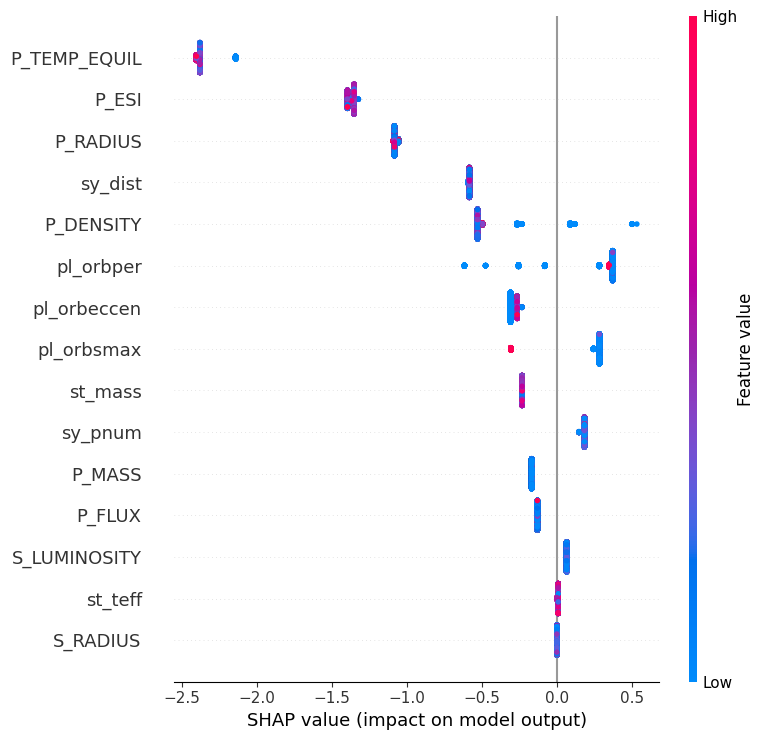

In [9]:
# Final fitted XGBoost model
xgb_model = final_pipe.named_steps["clf"]

# SHAP explainer
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_trainval)

# Summary plot
shap.summary_plot(shap_values, X_trainval, feature_names=X_trainval.columns)

In [15]:

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.2,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

In [16]:
feature_name_map = {
    "P_TEMP_EQUIL": "Equilibrium Temperature",
    "P_ESI": "Earth Similarity Index",
    "P_RADIUS": "Planet Radius",
    "P_DENSITY": "Planet Density",
    "P_MASS": "Planet Mass",
    "P_FLUX": "Incident Flux",
    "pl_orbper": "Orbital Period",
    "pl_orbeccen": "Orbital Eccentricity",
    "pl_orbsmax": "Semi-major Axis",
    "sy_dist": "System Distance",
    "sy_pnum": "Number of Planets",
    "st_mass": "Stellar Mass",
    "st_teff": "Stellar Effective Temperature",
    "S_LUMINOSITY": "Stellar Luminosity",
    "S_RADIUS": "Stellar Radius"
}

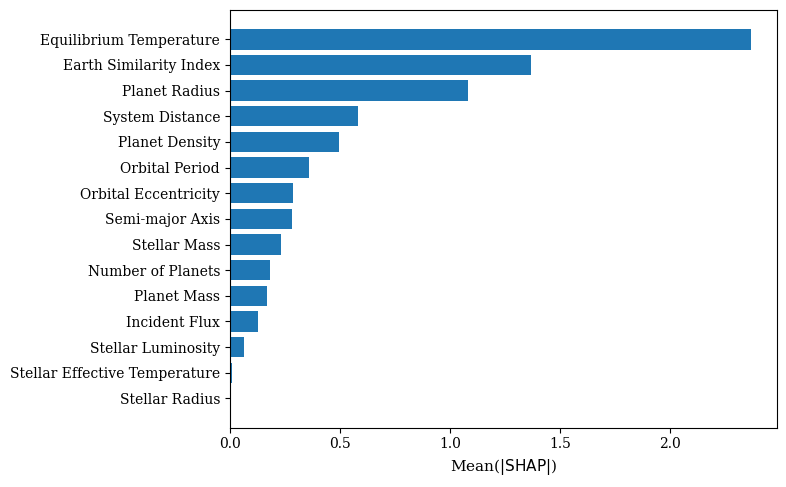

In [17]:
shap_importance = np.abs(shap_values).mean(axis=0)
indices = np.argsort(shap_importance)[::-1]

feature_labels = [
    feature_name_map.get(col, col)
    for col in np.array(X_trainval.columns)[indices]
]

plt.figure(figsize=(8, 5))
plt.barh(feature_labels, shap_importance[indices])
plt.gca().invert_yaxis()
plt.xlabel(r"Mean($|\mathrm{SHAP}|$)")
# plt.title("Global Feature Importance (SHAP)")
plt.tight_layout()

plt.savefig("shap.pdf")
plt.show();

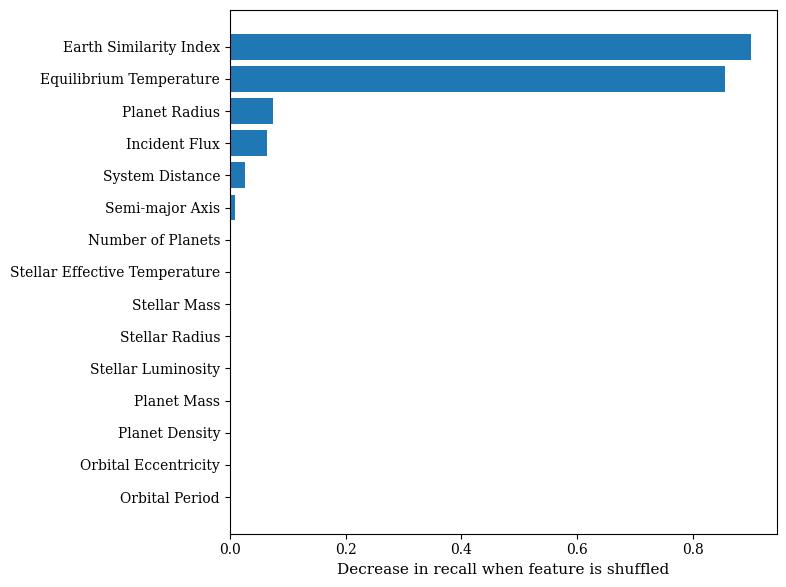

In [18]:
r = permutation_importance(final_pipe, X_test, y_test,
                           n_repeats=30, scoring="recall", random_state=42)

perm_sorted = r.importances_mean.argsort()[::-1]

feature_labels = [
    feature_name_map.get(col, col)
    for col in X.columns[perm_sorted]
]

plt.figure(figsize=(8,6))
plt.barh(feature_labels, r.importances_mean[perm_sorted])
plt.gca().invert_yaxis()
# plt.title("Permutation Importance (recall)")
plt.xlabel("Decrease in recall when feature is shuffled")
plt.tight_layout()

plt.savefig("perm.pdf")
plt.show();

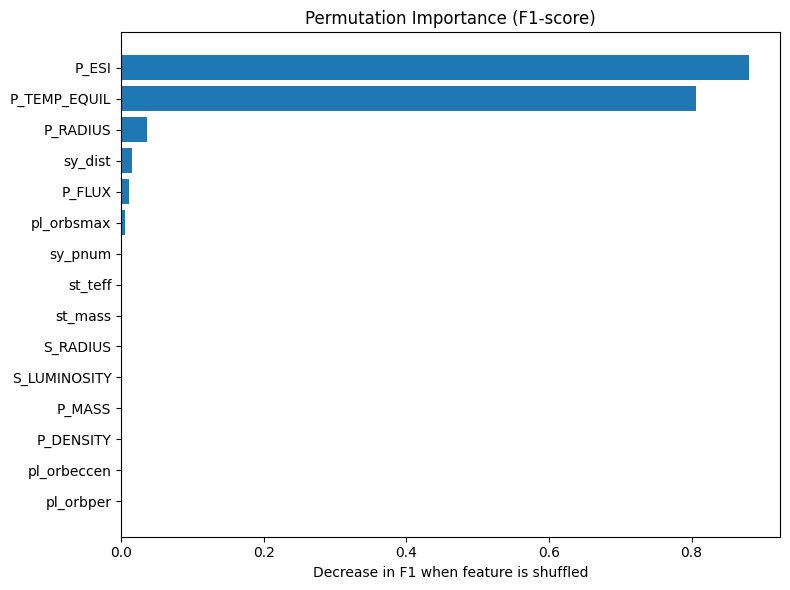

In [12]:
r = permutation_importance(final_pipe, X_test, y_test,
                           n_repeats=30, scoring="f1", random_state=42)

perm_sorted = r.importances_mean.argsort()[::-1]
plt.figure(figsize=(8,6))
plt.barh(X.columns[perm_sorted], r.importances_mean[perm_sorted])
plt.gca().invert_yaxis()
plt.title("Permutation Importance (F1-score)")
plt.xlabel("Decrease in F1 when feature is shuffled")
plt.tight_layout()
plt.show();

In [13]:
cv_results

{'RandomForest': {'recall_mean': np.float64(0.879090909090909),
  'recall_std': np.float64(0.0860968766931097),
  'precision_mean': np.float64(0.9832867132867134),
  'precision_std': np.float64(0.04094899069644575),
  'f1_mean': np.float64(0.9253106758992342),
  'f1_std': np.float64(0.049183024834629004),
  'bal_acc_mean': np.float64(0.9394254641032345),
  'bal_acc_std': np.float64(0.04299918369105571),
  'auc_mean': np.float64(0.9997449954474924),
  'auc_std': np.float64(0.0004454035081077068)},
 'XGBoost': {'recall_mean': np.float64(0.9206060606060606),
  'recall_std': np.float64(0.08254781289738337),
  'precision_mean': np.float64(0.9501468531468531),
  'precision_std': np.float64(0.05953450941743448),
  'f1_mean': np.float64(0.9331468632054445),
  'f1_std': np.float64(0.06160161414334897),
  'bal_acc_mean': np.float64(0.9599671261571993),
  'bal_acc_std': np.float64(0.04137121436124127),
  'auc_mean': np.float64(0.9996862708458139),
  'auc_std': np.float64(0.00030432843064481335)},

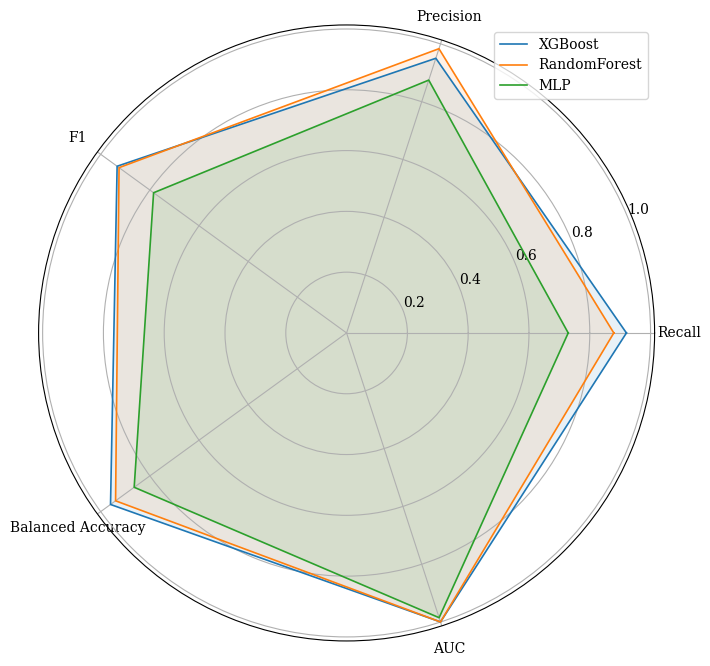

In [24]:
metrics = ["Recall", "Precision", "F1", "Balanced Accuracy", "AUC"]
models = ["XGBoost", "RandomForest", "MLP"]

# Fill with your cv_results
scores = np.array([
    [cv_results['XGBoost']["recall_mean"], cv_results['XGBoost']["precision_mean"], cv_results['XGBoost']["f1_mean"],
     cv_results['XGBoost']["bal_acc_mean"], cv_results['XGBoost']["auc_mean"]],
    [cv_results['RandomForest']["recall_mean"], cv_results['RandomForest']["precision_mean"], cv_results['RandomForest']["f1_mean"],
     cv_results['RandomForest']["bal_acc_mean"], cv_results['RandomForest']["auc_mean"]],
    [cv_results['MLP']["recall_mean"], cv_results['MLP']["precision_mean"], cv_results['MLP']["f1_mean"],
     cv_results['MLP']["bal_acc_mean"], cv_results['MLP']["auc_mean"]],
])

angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False)
scores = np.concatenate((scores, scores[:,0:1]), axis=1)
angles = np.concatenate((angles, [angles[0]]))

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

for i, model in enumerate(models):
    ax.plot(angles, scores[i], label=model)
    ax.fill(angles, scores[i], alpha=0.1)

ax.set_thetagrids(angles[:-1] * 180/np.pi, metrics)
ax.tick_params(axis='x', pad=7)
ax.legend()
# plt.title("Model Performance Comparison Across Metrics")

plt.savefig("spider.pdf")
plt.show();